### Project: 'MODELO PREDICTIVO DE CLASIFICACIÓN DE CHURN BASADO EN PATRONES DE CONTACTO PARA UNA STARTUP BOLIVIANA'  
#### Author: Flavia Davila Perez
##### Stage: MODELADO
Description: Implementacion de algoritmos de ML para la prediccion de 'Churn Comercial'

### Sección 1: Importacion de Librerias

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


### Sección 2:  Carga de Datos

In [2]:
# import CSV to DataFrame
df = pd.read_csv(r'..\data\output_gold\contact_metrics_clean.csv')

### Sección 3: Selección de Variables

In [3]:
num_columns_com = [
    'Total_Actividades_com', 
    'Total_Llamadas_com', 
    'Llamadas_Efectivas_com',
    'Llamadas_No_Efectivas_com', 
    'WA_Seguimiento_com', 
    'Reuniones_Hechas', 
    'Reuniones_Canceladas',
]

num_columns_exp = [
    'Total_Actividades_exp', 
    'Total_Llamadas_exp',
    'Llamadas_Efectivas_exp',
    'Llamadas_No_Efectivas_exp', 
    'WA_Seguimiento_exp', 
    'Kickoff_Hechas',
    'Kickoff_Canceladas',
    'Capacitaciones_Hechas', 
    'Capacitaciones_Canceladas'
]

cat_columns = [
    'Tipo de cliente',
    'Tipo Primer Contacto',
    'Rango de Contacto',
    'Tipo Primera Capacitación',
    'Onboarding',
    '(C) (EXP) Plazo y Pago',
    'R1yR2'
    ]

label = ['Churn Comercial']

In [4]:
subset_cols= num_columns_com + num_columns_exp + label
df_subset = df[subset_cols]

#### ANALISIS DE CORRELACION LINEAL 

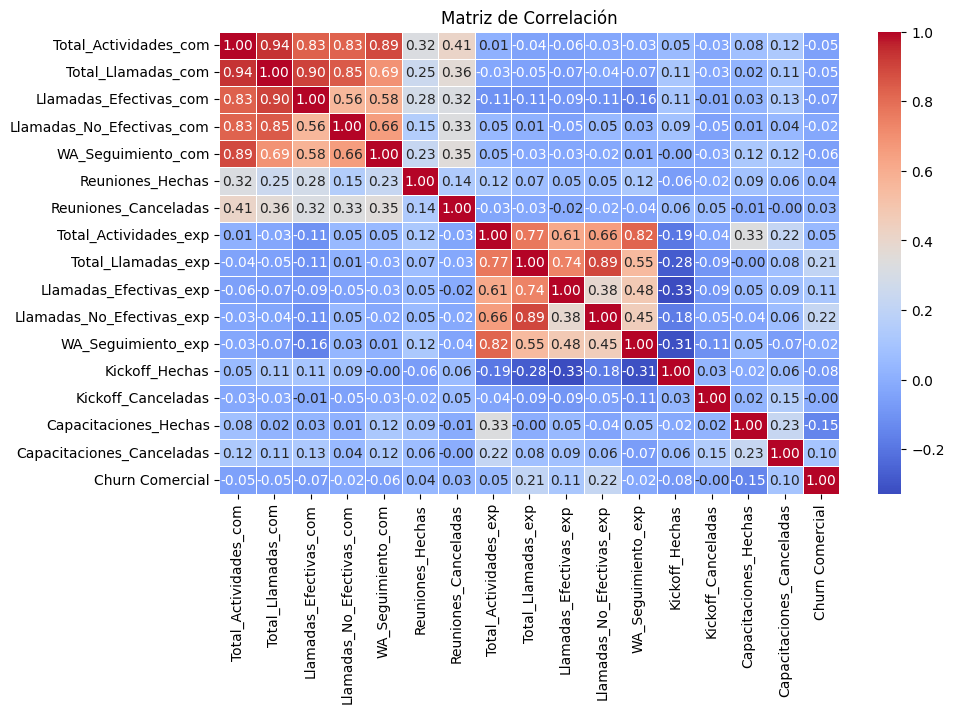

In [5]:
corr_matrix = df_subset.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

#### PRUEBA CHI CUADRADO ENTRE CUALITATIVAS

In [6]:
# Lista de variables cualitativas a comparar con 'Churn Comercial'
categorical_vars = [
    'Tipo de cliente', 
    'Tipo Primer Contacto', 
    'Rango de Contacto', 
    'Tipo Primera Capacitación', 
    'Onboarding',
    '(C) (EXP) Plazo y Pago',
    'R1yR2', 
    'New Categories'
]

# Variable de etiqueta (Churn Comercial)
target_var = 'Churn Comercial'

# Comparar cada variable cualitativa con 'Churn Comercial'
for cat_var in categorical_vars:
    # Crear la tabla de contingencia
    table = pd.crosstab(df[cat_var], df[target_var])

    # Aplicar la prueba Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(table)

    # Mostrar siempre los resultados
    print(f"🔍 Análisis de {cat_var} vs 'Churn Comercial'")
    print(f"   📌 Estadístico Chi-cuadrado: {chi2:.4f}")
    print(f"   📌 P-valor: {p}")
    print(f"   📌 Grados de libertad: {dof}")

    # Interpretación de significancia
    if p < 0.05:
        print(f"   ✅ Relación significativa (p < 0.05) entre {cat_var} y 'Churn Comercial'\n")
    else:
        print(f"   ❌ No hay relación significativa (p ≥ 0.05) entre {cat_var} y 'Churn Comercial'\n")

🔍 Análisis de Tipo de cliente vs 'Churn Comercial'
   📌 Estadístico Chi-cuadrado: 0.0031
   📌 P-valor: 0.998472939616131
   📌 Grados de libertad: 2
   ❌ No hay relación significativa (p ≥ 0.05) entre Tipo de cliente y 'Churn Comercial'

🔍 Análisis de Tipo Primer Contacto vs 'Churn Comercial'
   📌 Estadístico Chi-cuadrado: 3.9511
   📌 P-valor: 0.2667979728699163
   📌 Grados de libertad: 3
   ❌ No hay relación significativa (p ≥ 0.05) entre Tipo Primer Contacto y 'Churn Comercial'

🔍 Análisis de Rango de Contacto vs 'Churn Comercial'
   📌 Estadístico Chi-cuadrado: 0.9011
   📌 P-valor: 0.637262856883212
   📌 Grados de libertad: 2
   ❌ No hay relación significativa (p ≥ 0.05) entre Rango de Contacto y 'Churn Comercial'

🔍 Análisis de Tipo Primera Capacitación vs 'Churn Comercial'
   📌 Estadístico Chi-cuadrado: 2.5199
   📌 P-valor: 0.11242019859148769
   📌 Grados de libertad: 1
   ❌ No hay relación significativa (p ≥ 0.05) entre Tipo Primera Capacitación y 'Churn Comercial'

🔍 Análisis de O

#### PRUEBA ANOVA PARA VARIABLES CUANTITATIVAS

In [7]:
# Lista de variables cuantitativas a comparar con 'Churn Comercial'
quantitative_vars= num_columns_com + num_columns_exp 
df_subset = df[subset_cols]

# Variable de etiqueta (Churn Comercial)
target_var = 'Churn Comercial'

# Comparar cada variable cuantitativa con 'Churn Comercial'
for quant_var in quantitative_vars:
    # Dividir los datos en dos grupos según el valor de 'Churn Comercial'
    group1 = df[df[target_var] == 0][quant_var]
    group2 = df[df[target_var] == 1][quant_var]

    # Aplicar la prueba ANOVA
    f_stat, p_value = f_oneway(group1, group2)

    # Mostrar siempre los resultados
    print(f"🔍 Análisis de {quant_var} vs 'Churn Comercial'")
    print(f"   📌 Estadístico F: {f_stat:.4f}")
    print(f"   📌 P-valor: {p_value}")

    # Interpretación de significancia
    if p_value < 0.05:
        print(f"   ✅ Relación significativa (p < 0.05) entre {quant_var} y 'Churn Comercial'\n")
    else:
        print(f"   ❌ No hay relación significativa (p ≥ 0.05) entre {quant_var} y 'Churn Comercial'\n")


🔍 Análisis de Total_Actividades_com vs 'Churn Comercial'
   📌 Estadístico F: 0.9693
   📌 P-valor: 0.32549985240279855
   ❌ No hay relación significativa (p ≥ 0.05) entre Total_Actividades_com y 'Churn Comercial'

🔍 Análisis de Total_Llamadas_com vs 'Churn Comercial'
   📌 Estadístico F: 0.9741
   📌 P-valor: 0.32431500846206096
   ❌ No hay relación significativa (p ≥ 0.05) entre Total_Llamadas_com y 'Churn Comercial'

🔍 Análisis de Llamadas_Efectivas_com vs 'Churn Comercial'
   📌 Estadístico F: 1.6567
   📌 P-valor: 0.19885530967588033
   ❌ No hay relación significativa (p ≥ 0.05) entre Llamadas_Efectivas_com y 'Churn Comercial'

🔍 Análisis de Llamadas_No_Efectivas_com vs 'Churn Comercial'
   📌 Estadístico F: 0.2014
   📌 P-valor: 0.6538611443233595
   ❌ No hay relación significativa (p ≥ 0.05) entre Llamadas_No_Efectivas_com y 'Churn Comercial'

🔍 Análisis de WA_Seguimiento_com vs 'Churn Comercial'
   📌 Estadístico F: 1.2422
   📌 P-valor: 0.2657660891678207
   ❌ No hay relación significat

#### SELECCION DE VARIABLES

In [8]:
# seleccion final de variables
df_subset = df[[
    "Llamadas_Efectivas_com",
    "WA_Seguimiento_com",
    "Llamadas_Efectivas_exp",
    "Llamadas_No_Efectivas_exp",
    "Capacitaciones_Hechas",
    "Capacitaciones_Canceladas",
    "R1yR2",
    "(C) (EXP) Plazo y Pago",
    "Tipo de cliente",
    "Churn Comercial"
]]

### Seccion 4: Procesamiento de Datos

In [9]:
features = [
    "(C) (EXP) Plazo y Pago",
    "Tipo de cliente"
    ]

dummies = pd.get_dummies(df_subset[features])
df_encoded = pd.concat([df_subset.drop(features, axis=1), dummies], axis=1)


In [10]:
df_encoded.columns

Index(['Llamadas_Efectivas_com', 'WA_Seguimiento_com',
       'Llamadas_Efectivas_exp', 'Llamadas_No_Efectivas_exp',
       'Capacitaciones_Hechas', 'Capacitaciones_Canceladas', 'R1yR2',
       'Churn Comercial', '(C) (EXP) Plazo y Pago_Anual',
       '(C) (EXP) Plazo y Pago_Mensual', '(C) (EXP) Plazo y Pago_Otros',
       'Tipo de cliente_A', 'Tipo de cliente_B', 'Tipo de cliente_C'],
      dtype='object')

In [11]:
# Separar features y target
X = df_encoded.drop(columns=['Churn Comercial'])  
y = df_encoded['Churn Comercial'] 


### Sección 5: Creacion de conjuntos de Entrenamiento y Pruebas

In [12]:
# Dividir datos en train y test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


In [13]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE en el conjunto de entrenamiento y comparar composiciones de la clase minoritaria
smote_compar = SMOTE(random_state=42)
X_train_compar, y_train_compar = smote_compar.fit_resample(X_train, y_train)

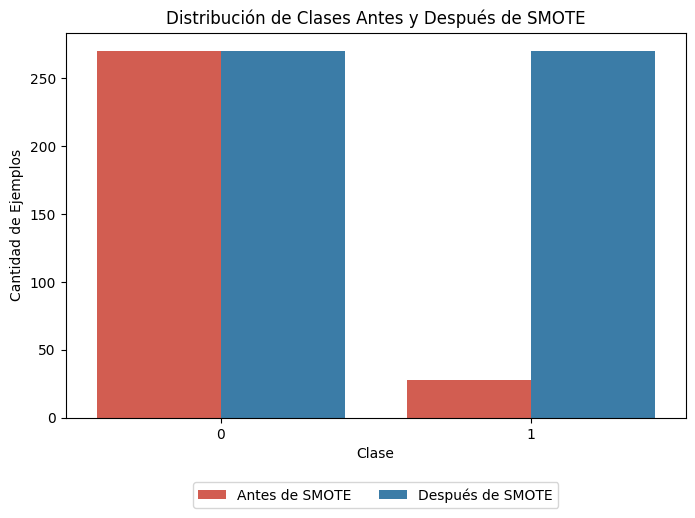

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Contar la cantidad de instancias antes y después de SMOTE
counter_before = Counter(y_train)
counter_after = Counter(y_train_compar)

# Crear DataFrame para graficar
df_counts = pd.DataFrame({
    "Clase": list(counter_before.keys()) * 2,
    "Cantidad": list(counter_before.values()) + list(counter_after.values()),
    "Estado": ["Antes de SMOTE"] * len(counter_before) + ["Después de SMOTE"] * len(counter_after)
})

# Graficar comparación de distribución de clases antes y después de SMOTE
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Clase", y="Cantidad", hue="Estado", data=df_counts, palette=["#E74C3C", "#2980B9"])
plt.title("Distribución de Clases Antes y Después de SMOTE")
plt.xlabel("Clase")
plt.ylabel("Cantidad de Ejemplos")

# Mover la leyenda debajo del gráfico
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.show()


### Sección 6: Entrenamiento de Modelos

### MODELO: Naive Bayes

##### Preliminar

Exactitud del modelo Naive Bayes: 0.8400
Precisión del modelo Naive Bayes: 0.3529

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.84      0.90        68
           1       0.35      0.86      0.50         7

    accuracy                           0.84        75
   macro avg       0.67      0.85      0.70        75
weighted avg       0.92      0.84      0.87        75


Matriz de Confusión en texto:
    0   1
0  57  11
1   1   6

Área bajo la Curva ROC (AUC-ROC): 0.9265


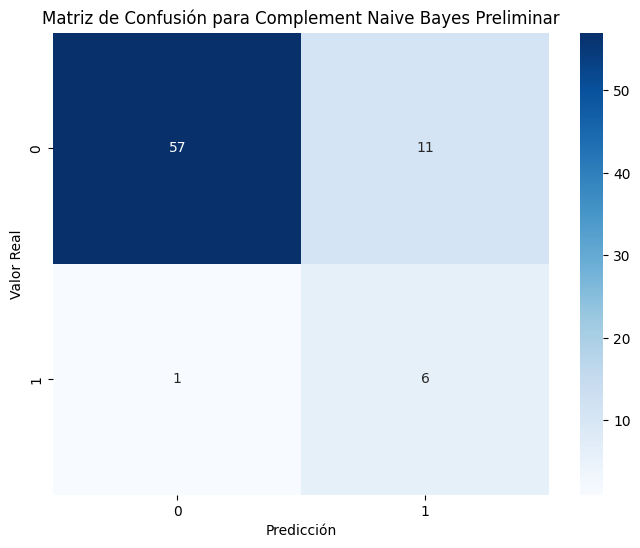

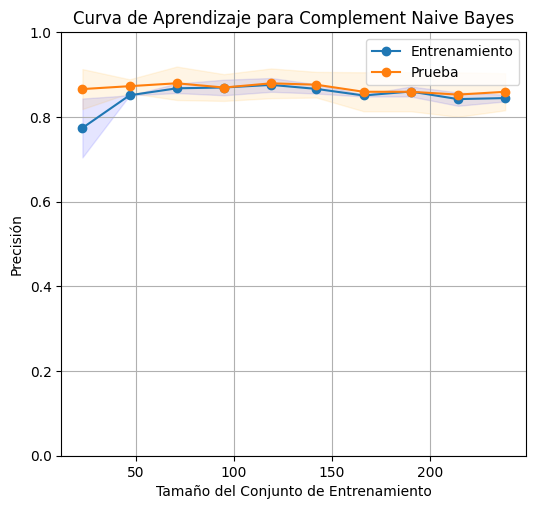

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 0.7739
Puntuación de Precisión (Prueba): 0.8658
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 4700%
Puntuación de Precisión (Entrenamiento): 0.8511
Puntuación de Precisión (Prueba): 0.8726
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7100%
Puntuación de Precisión (Entrenamiento): 0.8676
Puntuación de Precisión (Prueba): 0.8794
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 9500%
Puntuación de Precisión (Entrenamiento): 0.8695
Puntuación de Precisión (Prueba): 0.8694
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 11900%
Puntuación de Precisión (Entrenamiento): 0.8756
Puntuación de Precisión (Prueba): 0.8794
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 14200%
Puntuación de Precisión (Entrenamiento): 0.8662
Puntuación de 

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear y entrenar el modelo Complement Naive Bayes
naive_bayes = ComplementNB()
naive_bayes.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = naive_bayes.predict(X_test)

# Calcular la exactitud
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo Naive Bayes: {accuracy:.4f}")

# Calcular la precisión 
precision = precision_score(y_test, y_pred, average='binary') 
print(f"Precisión del modelo Naive Bayes: {precision:.4f}")

# Asegurar que las clases sean strings
target_names = [str(label) for label in naive_bayes.classes_]

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=target_names)
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=naive_bayes.classes_),
                             index=naive_bayes.classes_,
                             columns=naive_bayes.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para cada clase
y_proba = naive_bayes.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva
auc_roc = roc_auc_score(y_test, y_proba)

# Imprimir el AUC-ROC para cada clase
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=naive_bayes.classes_, yticklabels=naive_bayes.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Complement Naive Bayes Preliminar')
plt.show()

# Calcular la curva de aprendizaje para Complement Naive Bayes
train_sizes, train_scores, test_scores = learning_curve(
    naive_bayes, X_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular medias y desviaciones estándar de los puntajes
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.title('Curva de Aprendizaje para Complement Naive Bayes')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylim(0, 1)  # Ajustar el rango del eje Y
plt.ylabel('Precisión')
plt.legend(loc='best')
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_mean, test_mean in zip(train_sizes, train_scores_mean, test_scores_mean):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {train_mean:.4f}")
    print(f"Puntuación de Precisión (Prueba): {test_mean:.4f}")
    print("-" * 40)

##### Aplicacion de SMOTE 

Exactitud del modelo Naive Bayes: 0.8800
Precisión del modelo Naive Bayes: 0.4286

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93        68
           1       0.43      0.86      0.57         7

    accuracy                           0.88        75
   macro avg       0.71      0.87      0.75        75
weighted avg       0.93      0.88      0.90        75


Matriz de Confusión en texto:
    0  1
0  60  8
1   1  6

Área bajo la Curva ROC (AUC-ROC): 0.9328


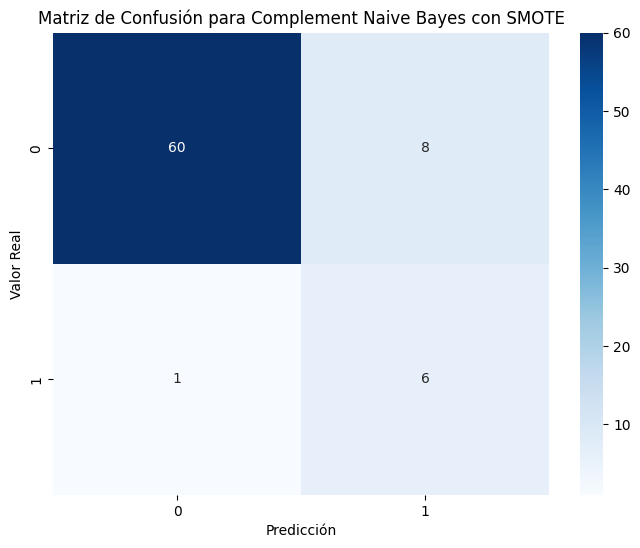

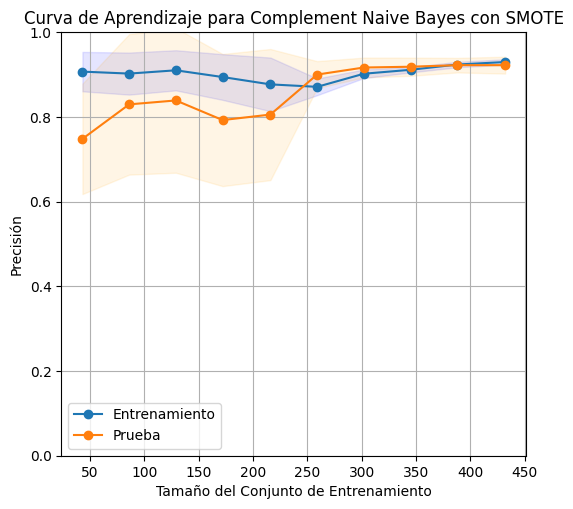

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 4300%
Puntuación de Precisión (Entrenamiento): 0.9070
Puntuación de Precisión (Prueba): 0.7481
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 8600%
Puntuación de Precisión (Entrenamiento): 0.9023
Puntuación de Precisión (Prueba): 0.8296
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 12900%
Puntuación de Precisión (Entrenamiento): 0.9101
Puntuación de Precisión (Prueba): 0.8389
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 17200%
Puntuación de Precisión (Entrenamiento): 0.8942
Puntuación de Precisión (Prueba): 0.7926
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 21600%
Puntuación de Precisión (Entrenamiento): 0.8769
Puntuación de Precisión (Prueba): 0.8056
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 25900%
Puntuación de Precisión (Entrenamiento): 0.8710
Puntuación d

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Aplicar SMOTE en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Crear y entrenar el modelo Complement Naive Bayes con datos balanceados
naive_bayes = ComplementNB()
naive_bayes.fit(X_train_bal, y_train_bal)

# Realizar predicciones en el conjunto de prueba
y_pred = naive_bayes.predict(X_test)

# Calcular la exactitud
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo Naive Bayes: {accuracy:.4f}")

# Calcular la precisión
precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo Naive Bayes: {precision:.4f}")

# Asegurar que las clases sean strings
target_names = [str(label) for label in naive_bayes.classes_]

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=target_names)
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=naive_bayes.classes_),
                             index=naive_bayes.classes_,
                             columns=naive_bayes.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para la clase positiva
y_proba = naive_bayes.predict_proba(X_test)[:, 1] 
auc_roc = roc_auc_score(y_test, y_proba)

# Imprimir el AUC-ROC
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=naive_bayes.classes_, yticklabels=naive_bayes.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Complement Naive Bayes con SMOTE')
plt.show()

# Calcular la curva de aprendizaje para Complement Naive Bayes
train_sizes, train_scores, test_scores = learning_curve(
    naive_bayes, X_train_bal, y_train_bal, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular medias y desviaciones estándar de los puntajes
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.title('Curva de Aprendizaje para Complement Naive Bayes con SMOTE')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylim(0, 1)  # Ajustar el rango del eje Y
plt.ylabel('Precisión')
plt.legend(loc='best')
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_mean, test_mean in zip(train_sizes, train_scores_mean, test_scores_mean):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {train_mean:.4f}")
    print(f"Puntuación de Precisión (Prueba): {test_mean:.4f}")
    print("-" * 40)


##### Ajustado

Exactitud del modelo Complement Naive Bayes después del ajuste: 0.8800
Precisión del modelo Complement Naive Bayes después del ajuste: 0.4375

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        68
           1       0.44      1.00      0.61         7

    accuracy                           0.88        75
   macro avg       0.72      0.93      0.77        75
weighted avg       0.95      0.88      0.90        75


Matriz de Confusión en texto:
    0  1
0  59  9
1   0  7

Área bajo la Curva ROC (AUC-ROC): 0.9328


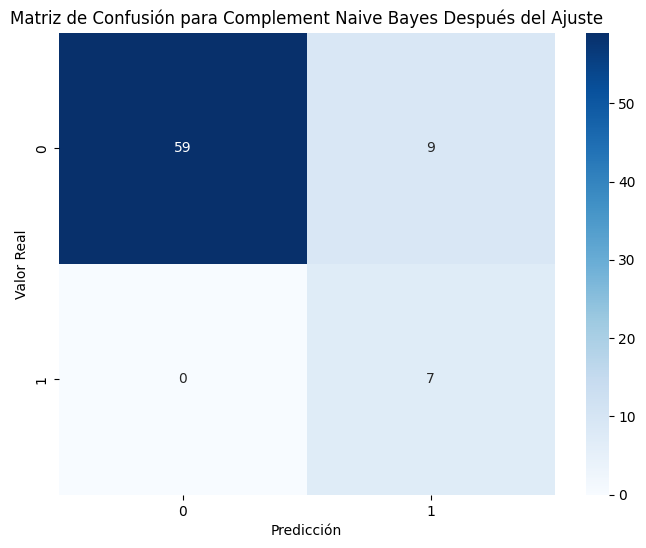

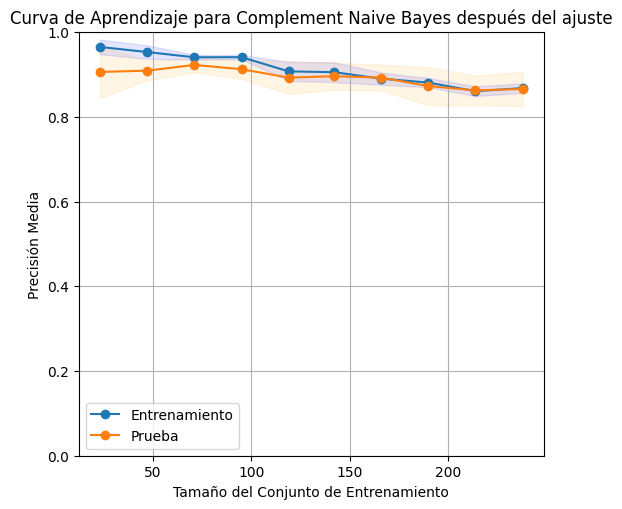

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 0.9652
Puntuación de Precisión (Prueba): 0.9062
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 4700%
Puntuación de Precisión (Entrenamiento): 0.9532
Puntuación de Precisión (Prueba): 0.9093
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7100%
Puntuación de Precisión (Entrenamiento): 0.9408
Puntuación de Precisión (Prueba): 0.9228
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 9500%
Puntuación de Precisión (Entrenamiento): 0.9411
Puntuación de Precisión (Prueba): 0.9127
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 11900%
Puntuación de Precisión (Entrenamiento): 0.9076
Puntuación de Precisión (Prueba): 0.8928
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 14200%
Puntuación de Precisión (Entrenamiento): 0.9056
Puntuación de 

In [17]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
import seaborn as sns

# Realizar SMOTE para balancear las clases 
smote = SMOTE(sampling_strategy=0.6, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Definir el modelo Complement Naive Bayes
complement_nb = ComplementNB(class_prior=[0.1, 0.9])

# Definir los hiperparámetros a ajustar
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'norm': [True, False]
}

# Configurar la estrategia de validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la búsqueda de hiperparámetros con validación cruzada
grid_search = GridSearchCV(complement_nb, param_grid, scoring='precision', cv=cv)
grid_search.fit(X_train_bal, y_train_bal)

# Obtener el mejor modelo después del ajuste
best_complement_nb = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = best_complement_nb.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo Complement Naive Bayes después del ajuste: {accuracy:.4f}")

# Calcular la precisión
precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo Complement Naive Bayes después del ajuste: {precision:.4f}")

# Asegurar que las clases sean strings
target_names = [str(label) for label in best_complement_nb.classes_]

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=target_names)
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=best_complement_nb.classes_),
                             index=best_complement_nb.classes_,
                             columns=best_complement_nb.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para la clase positiva
y_proba = best_complement_nb.predict_proba(X_test)[:, 1] 
auc_roc = roc_auc_score(y_test, y_proba)

# Imprimir el AUC-ROC
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular la curva de aprendizaje para Complement Naive Bayes
train_sizes, train_scores, test_scores = learning_curve(
    best_complement_nb, X_train, y_train, cv=cv, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular y graficar la matriz de confusión (opcional)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=best_complement_nb.classes_, yticklabels=best_complement_nb.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Complement Naive Bayes Después del Ajuste')
plt.show()

# Calcular las medias y desviaciones estándar de los puntajes
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje con intervalos de confianza
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Entrenamiento')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Prueba')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Precisión Media')
plt.title('Curva de Aprendizaje para Complement Naive Bayes después del ajuste')
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)

### MODELO: LogisticRegression




#### Preliminar

Vamos a prescindir de algunas variables dummies para evitar Multicolinealidad perfecta

In [18]:
df_for_LR = df_encoded[[
    'Llamadas_Efectivas_com', 
    'WA_Seguimiento_com',
    'Llamadas_Efectivas_exp', 
    'Llamadas_No_Efectivas_exp',
    'Capacitaciones_Hechas', 
    'Capacitaciones_Canceladas', 
    'R1yR2',
    '(C) (EXP) Plazo y Pago_Anual',
    '(C) (EXP) Plazo y Pago_Mensual', 
    'Tipo de cliente_B', 
    'Tipo de cliente_C',
    'Churn Comercial']]

In [19]:
# Separar features y target
X_1 = df_for_LR.drop(columns=['Churn Comercial'])  
y_1 = df_for_LR['Churn Comercial'] 

In [20]:
# Dividir datos en train y test 
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1, y_1, test_size=0.20, random_state=42, stratify=y_1)

Exactitud del modelo de Regresión Logística: 0.8800
Precisión del modelo de Regresión Logística: 0.0000

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94        68
           1       0.00      0.00      0.00         7

    accuracy                           0.88        75
   macro avg       0.45      0.49      0.47        75
weighted avg       0.82      0.88      0.85        75


Matriz de Confusión en texto:
    0  1
0  66  2
1   7  0

Área bajo la Curva ROC (AUC-ROC): 0.9454


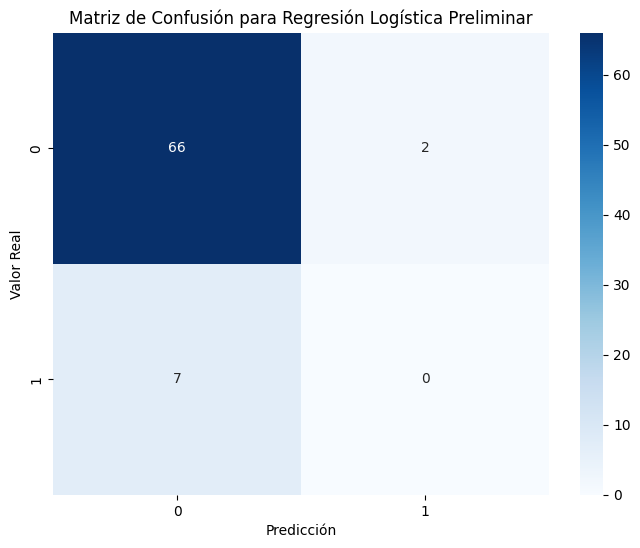

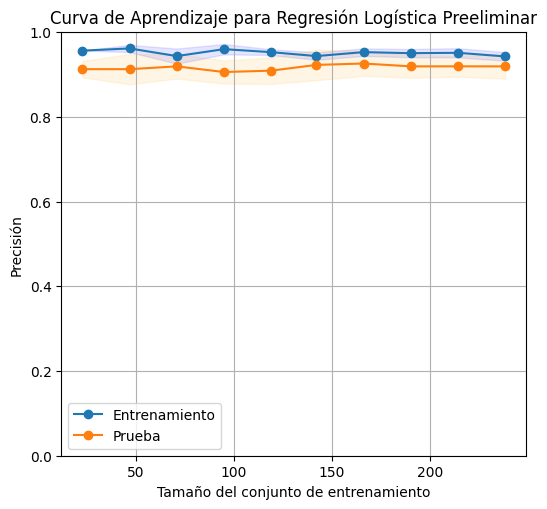

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 0.9565
Puntuación de Precisión (Prueba): 0.9128
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 4700%
Puntuación de Precisión (Entrenamiento): 0.9617
Puntuación de Precisión (Prueba): 0.9128
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7100%
Puntuación de Precisión (Entrenamiento): 0.9437
Puntuación de Precisión (Prueba): 0.9194
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 9500%
Puntuación de Precisión (Entrenamiento): 0.9600
Puntuación de Precisión (Prueba): 0.9060
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 11900%
Puntuación de Precisión (Entrenamiento): 0.9529
Puntuación de Precisión (Prueba): 0.9093
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 14200%
Puntuación de Precisión (Entrenamiento): 0.9437
Puntuación de 

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, KFold
import seaborn as sns
import pandas as pd
import numpy as np

# Crear y entrenar el modelo de Regresión Logística
logistic_regression = LogisticRegression()
logistic_regression.fit(X_1_train, y_1_train)

# Realizar predicciones en el conjunto de prueba
y_pred = logistic_regression.predict(X_1_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_1_test, y_pred)
print(f"Exactitud del modelo de Regresión Logística: {accuracy:.4f}")

# Calcular métricas de evaluación
precision = precision_score(y_1_test, y_pred, average='binary')
print(f"Precisión del modelo de Regresión Logística: {precision:.4f}")

# Calcular el informe de clasificación
report = classification_report(y_1_test, y_pred, 
                               target_names=[str(label) for label in logistic_regression.classes_])
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_1_test, y_pred, labels=logistic_regression.classes_),
                             index=logistic_regression.classes_,
                             columns=logistic_regression.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para cada clase
y_proba = logistic_regression.predict_proba(X_1_test)[:, 1]  # Probabilidad de la clase positiva
auc_roc = roc_auc_score(y_1_test, y_proba)

# Imprimir el AUC-ROC para cada clase
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión (opcional)
cm = confusion_matrix(y_1_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=logistic_regression.classes_, yticklabels=logistic_regression.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Regresión Logística Preliminar')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    logistic_regression, X_1_train, y_1_train, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular la media y la desviación estándar de las puntuaciones de entrenamiento y prueba
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')

plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Precisión')
plt.title('Curva de Aprendizaje para Regresión Logística Preeliminar')
plt.ylim(0, 1)  # Ajustar el rango del eje
plt.grid()
plt.legend()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


#### Aplicando SMOTE

Exactitud del modelo de Regresión Logística: 0.9200
Precisión del modelo de Regresión Logística: 0.5385

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        68
           1       0.54      1.00      0.70         7

    accuracy                           0.92        75
   macro avg       0.77      0.96      0.83        75
weighted avg       0.96      0.92      0.93        75


Matriz de Confusión en texto:
    0  1
0  62  6
1   0  7

Área bajo la Curva ROC (AUC-ROC): 0.9370


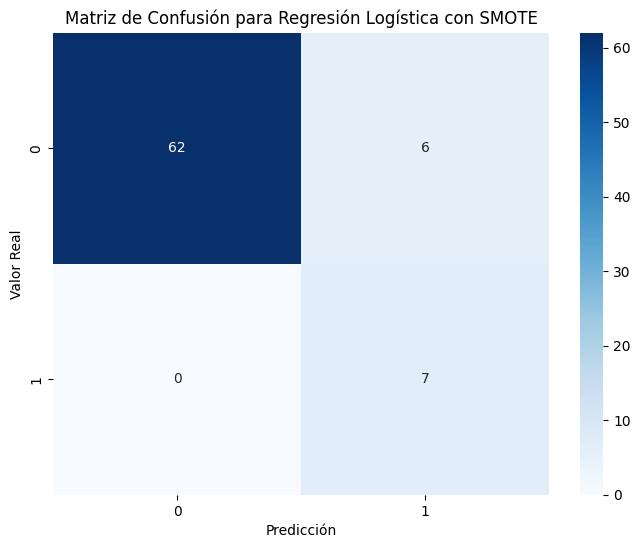

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\AppData\Loca

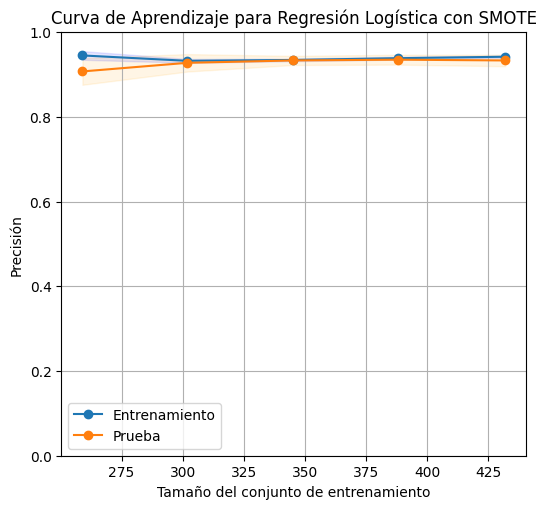

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 4300%
Puntuación de Precisión (Entrenamiento): nan
Puntuación de Precisión (Prueba): nan
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 8600%
Puntuación de Precisión (Entrenamiento): nan
Puntuación de Precisión (Prueba): nan
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 12900%
Puntuación de Precisión (Entrenamiento): nan
Puntuación de Precisión (Prueba): nan
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 17200%
Puntuación de Precisión (Entrenamiento): nan
Puntuación de Precisión (Prueba): nan
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 21600%
Puntuación de Precisión (Entrenamiento): nan
Puntuación de Precisión (Prueba): nan
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 25900%
Puntuación de Precisión (Entrenamiento): 0.9452
Puntuación de Precisión (Prueba): 0.9074
-

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, KFold
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE para balancear las clases
smote = SMOTE(random_state=42)
X_1_train_bal, y_1_train_bal = smote.fit_resample(X_1_train, y_1_train)

# Crear y entrenar el modelo de Regresión Logística
logistic_regression = LogisticRegression()
logistic_regression.fit(X_1_train_bal, y_1_train_bal)

# Realizar predicciones en el conjunto de prueba
y_pred = logistic_regression.predict(X_1_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_1_test, y_pred)
print(f"Exactitud del modelo de Regresión Logística: {accuracy:.4f}")

# Calcular métricas de evaluación
precision = precision_score(y_1_test, y_pred, average='binary')
print(f"Precisión del modelo de Regresión Logística: {precision:.4f}")

# Calcular el informe de clasificación
report = classification_report(y_1_test, y_pred, 
                               target_names=[str(label) for label in logistic_regression.classes_])
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_1_test, y_pred, labels=logistic_regression.classes_),
                             index=logistic_regression.classes_,
                             columns=logistic_regression.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para cada clase
y_proba = logistic_regression.predict_proba(X_1_test)[:, 1]  # Probabilidad de la clase positiva
auc_roc = roc_auc_score(y_1_test, y_proba)

# Imprimir el AUC-ROC para cada clase
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión (opcional)
cm = confusion_matrix(y_1_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=logistic_regression.classes_, yticklabels=logistic_regression.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Regresión Logística con SMOTE')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    logistic_regression, X_1_train_bal, y_1_train_bal, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular la media y la desviación estándar de las puntuaciones de entrenamiento y prueba
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')

plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Precisión')
plt.title('Curva de Aprendizaje para Regresión Logística con SMOTE')
plt.ylim(0, 1)  # Ajustar el rango del eje
plt.grid()
plt.legend()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


#### Ajustado

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_

Exactitud del modelo de Regresión Logística: 0.9200
Precisión del modelo de Regresión Logística: 0.6000

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        68
           1       0.60      0.43      0.50         7

    accuracy                           0.92        75
   macro avg       0.77      0.70      0.73        75
weighted avg       0.91      0.92      0.91        75


Matriz de Confusión en texto:
    0  1
0  66  2
1   4  3

Área bajo la Curva ROC (AUC-ROC): 0.9391


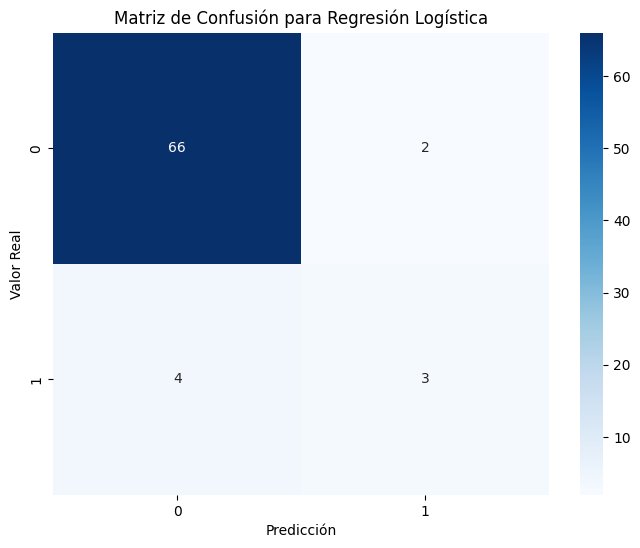

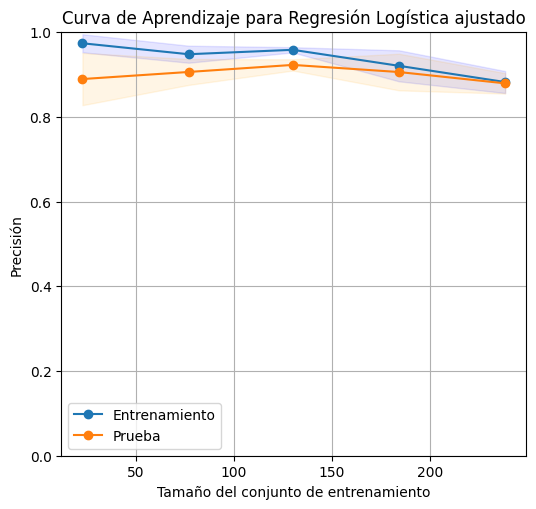

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 0.9739
Puntuación de Precisión (Prueba): 0.8894
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7700%
Puntuación de Precisión (Entrenamiento): 0.9481
Puntuación de Precisión (Prueba): 0.9062
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 13000%
Puntuación de Precisión (Entrenamiento): 0.9585
Puntuación de Precisión (Prueba): 0.9228
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 18400%
Puntuación de Precisión (Entrenamiento): 0.9207
Puntuación de Precisión (Prueba): 0.9060
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 23800%
Puntuación de Precisión (Entrenamiento): 0.8824
Puntuación de Precisión (Prueba): 0.8793
----------------------------------------


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Balanceo con SMOTE
smote = SMOTE(sampling_strategy=0.9,random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_1_train, y_1_train)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_1_test)

# Definir el modelo de Regresión Logística con clase balanceada
logistic_regression = LogisticRegression(max_iter=700, 
                                         class_weight = {0: 1, 1: 20}, 
                                         random_state=42)

# Definir los hiperparámetros a ajustar
param_grid = {
    'C': [ 0.01, 0.1, 1, 10, 100, 1000],  
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear', 'saga'],  
}

# Configurar la estrategia de validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la búsqueda de hiperparámetros con validación cruzada
grid_search = GridSearchCV(logistic_regression, param_grid, scoring='precision', cv=cv)
grid_search.fit(X_train_scaled, y_train_bal)

# Obtener el mejor modelo después del ajuste
best_logistic_regression = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = best_logistic_regression.predict(X_1_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_1_test, y_pred)
print(f"Exactitud del modelo de Regresión Logística: {accuracy:.4f}")

# Calcular métricas de evaluación
precision = precision_score(y_1_test, y_pred, average='binary')
print(f"Precisión del modelo de Regresión Logística: {precision:.4f}")

# Calcular el informe de clasificación
report = classification_report(y_1_test, y_pred, target_names=[str(label) for label in best_logistic_regression.classes_])
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_1_test, y_pred, labels=best_logistic_regression.classes_),
                             index=best_logistic_regression.classes_,
                             columns=best_logistic_regression.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para cada clase
y_proba = best_logistic_regression.predict_proba(X_1_test)[:, 1]  # Probabilidad de la clase positiva
auc_roc = roc_auc_score(y_1_test, y_proba)

# Imprimir el AUC-ROC para cada clase
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión (opcional)
cm = confusion_matrix(y_1_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=best_logistic_regression.classes_, yticklabels=best_logistic_regression.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Regresión Logística')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(best_logistic_regression, X_1_train, y_1_train, cv=cv, scoring='accuracy', n_jobs=-1)

# Calcular las medias y desviaciones estándar de los puntajes
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)


# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="orange")
plt.plot(train_sizes, train_scores_mean, 'o-',  label="Entrenamiento")
plt.plot(train_sizes, test_scores_mean, 'o-',  label="Prueba")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión")
plt.legend(loc="best")
plt.ylim(0, 1)  # Ajustar el rango del eje y
plt.title("Curva de Aprendizaje para Regresión Logística ajustado")
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)

### MODELO: Decision Tree

##### Preliminar

Exactitud del modelo de Decision Tree: 0.9200
Precisión del modelo de Decision Tree: 0.5714

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        68
           1       0.57      0.57      0.57         7

    accuracy                           0.92        75
   macro avg       0.76      0.76      0.76        75
weighted avg       0.92      0.92      0.92        75


Matriz de Confusión en texto:
    0  1
0  65  3
1   3  4

Área bajo la Curva ROC (AUC-ROC): 0.7637


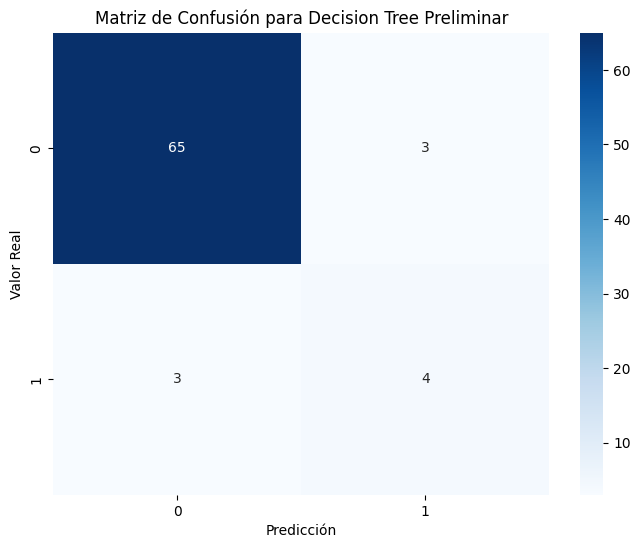

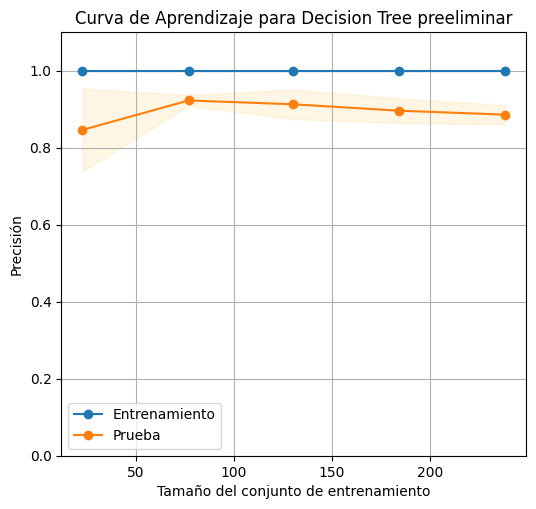

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.8462
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7700%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.9228
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 13000%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.9129
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 18400%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.8962
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 23800%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.8859
----------------------------------------


In [24]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Crear y ajustar el modelo DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = decision_tree.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo de Decision Tree: {accuracy:.4f}")

# Calcular métricas de evaluación
precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo de Decision Tree: {precision:.4f}")

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=[str(label) for label in decision_tree.classes_])
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=decision_tree.classes_),
                             index=decision_tree.classes_,
                             columns=decision_tree.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para cada clase
y_proba = decision_tree.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva
auc_roc = roc_auc_score(y_test, y_proba)

# Imprimir el AUC-ROC para cada clase
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Mostrar la matriz de confusión como un gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues", xticklabels=decision_tree.classes_, yticklabels=decision_tree.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Decision Tree Preliminar')

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(decision_tree, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

# Calcular las medias y desviaciones estándar de los puntajes
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6,5.5))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="orange")
plt.plot(train_sizes, train_scores_mean, 'o-', label="Entrenamiento")
plt.plot(train_sizes, test_scores_mean, 'o-', label="Prueba")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión")
plt.legend(loc="best")
plt.ylim(0, 1.1)  # Ajustar el rango del eje y
plt.title("Curva de Aprendizaje para Decision Tree preeliminar")
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)

##### Aplicando SMOTE

Exactitud del modelo de Decision Tree con SMOTE: 0.9333
Precisión del modelo de Decision Tree con SMOTE: 0.5833

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        68
           1       0.58      1.00      0.74         7

    accuracy                           0.93        75
   macro avg       0.79      0.96      0.85        75
weighted avg       0.96      0.93      0.94        75


Matriz de Confusión en texto:
    0  1
0  63  5
1   0  7

Área bajo la Curva ROC (AUC-ROC): 0.9706


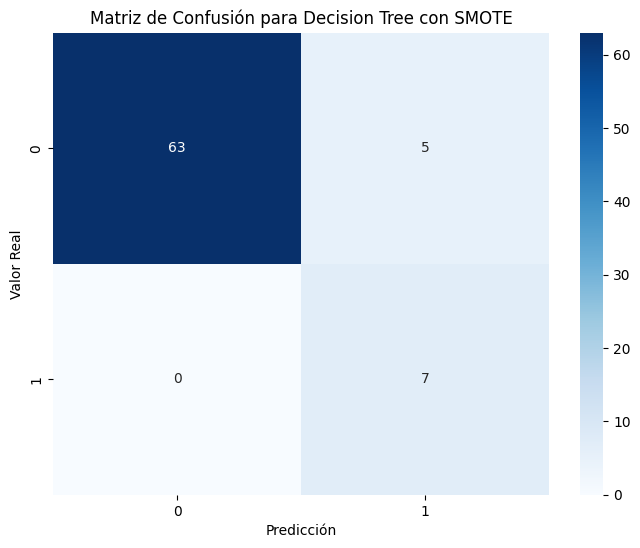

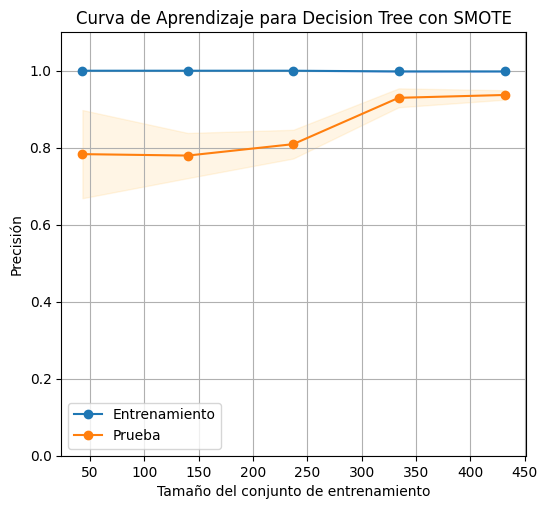

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 4300%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7833
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 14000%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7796
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 23700%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.8093
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 33400%
Puntuación de Precisión (Entrenamiento): 0.9982
Puntuación de Precisión (Prueba): 0.9296
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 43200%
Puntuación de Precisión (Entrenamiento): 0.9981
Puntuación de Precisión (Prueba): 0.9370
----------------------------------------


In [25]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicar SMOTE al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Crear y ajustar el modelo DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_bal, y_train_bal)

# Realizar predicciones en el conjunto de prueba
y_pred = decision_tree.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo de Decision Tree con SMOTE: {accuracy:.4f}")

precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo de Decision Tree con SMOTE: {precision:.4f}")

report = classification_report(y_test, y_pred, target_names=[str(label) for label in decision_tree.classes_])
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=decision_tree.classes_),
                             index=decision_tree.classes_,
                             columns=decision_tree.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC
y_proba = decision_tree.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Mostrar la matriz de confusión como un gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues", xticklabels=decision_tree.classes_, yticklabels=decision_tree.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Decision Tree con SMOTE')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(decision_tree, X_train_bal, y_train_bal, cv=cv, scoring='accuracy', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6,5.5))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="orange")
plt.plot(train_sizes, train_scores_mean, 'o-', label="Entrenamiento")
plt.plot(train_sizes, test_scores_mean, 'o-', label="Prueba")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión")
plt.legend(loc="best")
plt.ylim(0, 1.1)
plt.title("Curva de Aprendizaje para Decision Tree con SMOTE")
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


##### Ajustado

Exactitud del modelo de Decision Tree con SMOTE: 0.9333
Precisión del modelo de Decision Tree con SMOTE: 0.6250

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        68
           1       0.62      0.71      0.67         7

    accuracy                           0.93        75
   macro avg       0.80      0.84      0.81        75
weighted avg       0.94      0.93      0.94        75


Matriz de Confusión en texto:
    0  1
0  65  3
1   2  5

Área bajo la Curva ROC (AUC-ROC): 0.9706


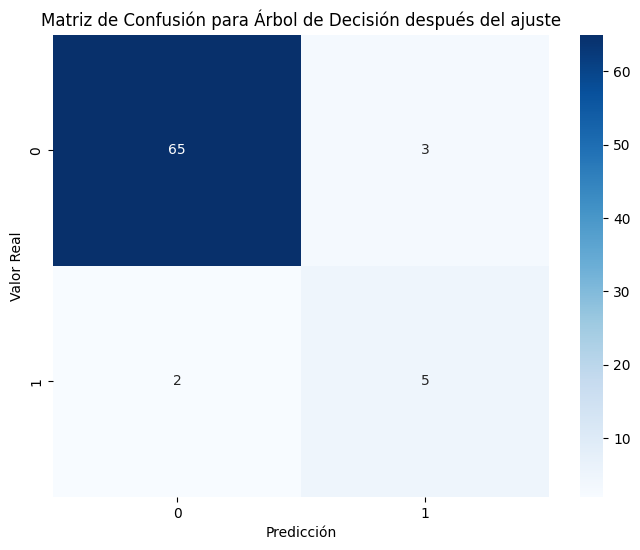

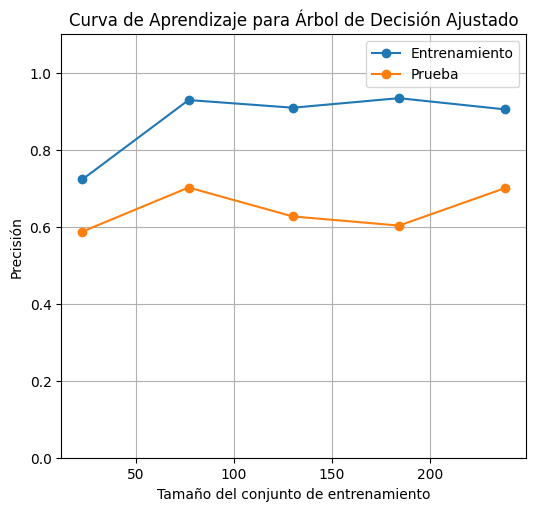

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 0.7230
Puntuación de Precisión (Prueba): 0.5874
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7700%
Puntuación de Precisión (Entrenamiento): 0.9291
Puntuación de Precisión (Prueba): 0.7018
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 13000%
Puntuación de Precisión (Entrenamiento): 0.9091
Puntuación de Precisión (Prueba): 0.6267
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 18400%
Puntuación de Precisión (Entrenamiento): 0.9339
Puntuación de Precisión (Prueba): 0.6030
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 23800%
Puntuación de Precisión (Entrenamiento): 0.9048
Puntuación de Precisión (Prueba): 0.7004
----------------------------------------


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Balanceo con SMOTE
smote = SMOTE(sampling_strategy=1, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Modelo base de DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)

# Definición de hiperparámetros
param_grid = {
    'criterion': ['entropy', 'log_loss'],  
    'max_depth': list(range(3, 15, 2)),  
    'min_samples_split': list(range(5, 20, 5)),  
    'min_samples_leaf': list(range(2, 10, 2)),  
    'class_weight': [None, 'balanced'], 
    'max_features': ['sqrt', 'log2']  
}

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Búsqueda en rejilla de hiperparámetros
grid_search = GridSearchCV(
    decision_tree, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='precision', 
    n_jobs=-1
)
grid_search.fit(X_train_bal, y_train_bal)

# Mejor modelo
best_decision_tree = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = best_decision_tree.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo de Decision Tree con SMOTE: {accuracy:.4f}")

precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo de Decision Tree con SMOTE: {precision:.4f}")

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=[str(label) for label in best_decision_tree.classes_])
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=best_decision_tree.classes_),
                             index=best_decision_tree.classes_,
                             columns=best_decision_tree.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC
y_proba = best_decision_tree.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva
auc_roc = roc_auc_score(y_test, y_proba)
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Mostrar la matriz de confusión como un gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues", xticklabels=best_decision_tree.classes_, yticklabels=best_decision_tree.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Árbol de Decisión después del ajuste')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(best_decision_tree, X_train, y_train, cv=cv, scoring='precision_macro', n_jobs=-1)

# Calcular las medias y desviaciones estándar de los puntajes
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Entrenamiento")
plt.plot(train_sizes, test_scores_mean, 'o-', label="Prueba")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión")
plt.legend(loc="best")
plt.ylim(0, 1.1)
plt.title("Curva de Aprendizaje para Árbol de Decisión Ajustado")
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


### MODELO: Random Forest

##### Preliminar

Exactitud del modelo de Random Forest: 0.9200
Precisión del modelo de Random Forest: 0.6000

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        68
           1       0.60      0.43      0.50         7

    accuracy                           0.92        75
   macro avg       0.77      0.70      0.73        75
weighted avg       0.91      0.92      0.91        75


Matriz de Confusión en texto:
    0  1
0  66  2
1   4  3

Área bajo la Curva ROC (AUC-ROC): 0.9317


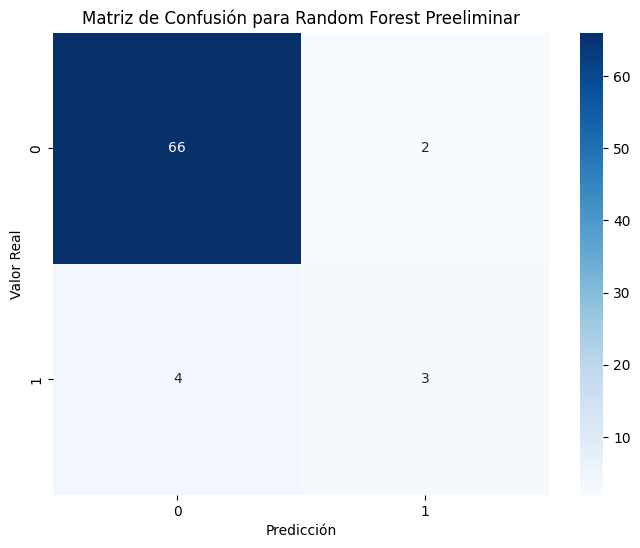

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

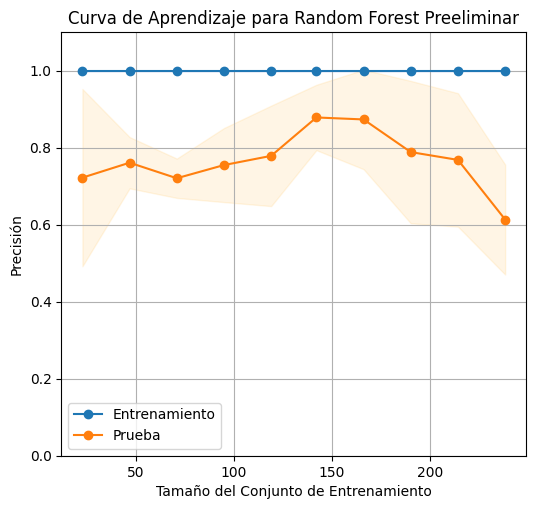

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7223
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 4700%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7611
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7100%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7207
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 9500%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7550
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 11900%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7789
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 14200%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de 

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import learning_curve
import numpy as np

# Crear y entrenar el modelo RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = random_forest.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo de Random Forest: {accuracy:.4f}")

# Calcular métricas de evaluación
precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo de Random Forest: {precision:.4f}")

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=[str(label) for label in random_forest.classes_])
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=random_forest.classes_),
                             index=random_forest.classes_,
                             columns=random_forest.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para cada clase
y_proba = random_forest.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva
auc_roc = roc_auc_score(y_test, y_proba)

# Imprimir el AUC-ROC para cada clase
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=random_forest.classes_, yticklabels=random_forest.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Random Forest Preeliminar')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    random_forest, X_train, y_train, cv=5, scoring='precision_macro', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular la media y la desviación estándar de las puntuaciones de entrenamiento y prueba
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.title('Curva de Aprendizaje para Random Forest Preeliminar')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Precisión')
plt.legend(loc='best')
plt.ylim(0, 1.1)  # Ajustar el rango del eje y
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)

##### Aplicando SMOTE

Exactitud del modelo de Random Forest con SMOTE: 0.9067
Precisión del modelo de Random Forest con SMOTE: 0.5000

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        68
           1       0.50      0.71      0.59         7

    accuracy                           0.91        75
   macro avg       0.73      0.82      0.77        75
weighted avg       0.93      0.91      0.91        75


Matriz de Confusión en texto:
    0  1
0  63  5
1   2  5

Área bajo la Curva ROC (AUC-ROC): 0.9401


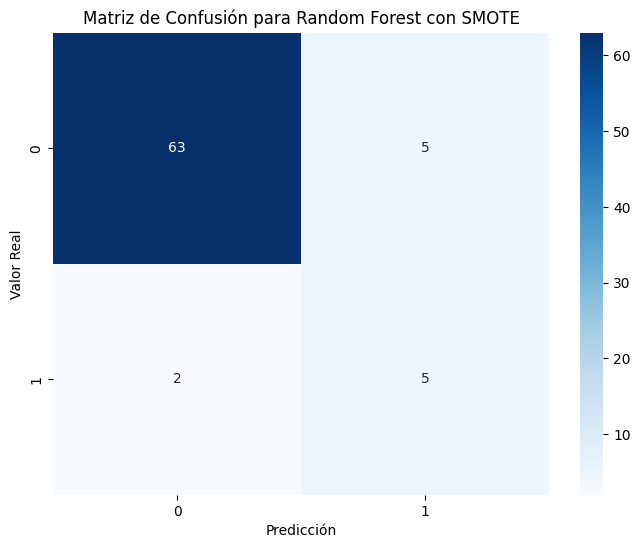

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

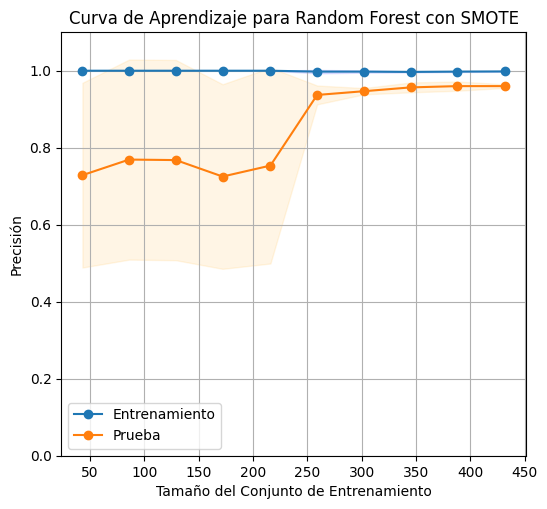

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 4300%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7287
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 8600%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7692
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 12900%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7679
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 17200%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7251
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 21600%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.7536
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 25900%
Puntuación de Precisión (Entrenamiento): 0.9977
Puntuación d

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import learning_curve
import numpy as np
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Crear y entrenar el modelo RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_bal, y_train_bal)

# Realizar predicciones en el conjunto de prueba
y_pred = random_forest.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo de Random Forest con SMOTE: {accuracy:.4f}")

precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo de Random Forest con SMOTE: {precision:.4f}")

report = classification_report(y_test, y_pred, target_names=[str(label) for label in random_forest.classes_])
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=random_forest.classes_),
                             index=random_forest.classes_,
                             columns=random_forest.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC
y_proba = random_forest.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=random_forest.classes_, yticklabels=random_forest.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Random Forest con SMOTE')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    random_forest, X_train_bal, y_train_bal, cv=5, scoring='precision_macro', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular la media y la desviación estándar de las puntuaciones de entrenamiento y prueba
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.title('Curva de Aprendizaje para Random Forest con SMOTE')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Precisión')
plt.legend(loc='best')
plt.ylim(0, 1.1)  # Ajustar el rango del eje y
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


##### Ajustado


Mejores hiperparámetros encontrados por GridSearchCV:
{'bootstrap': True, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Exactitud del modelo: 0.9067
Precisión del modelo: 0.5000

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        68
           1       0.50      1.00      0.67         7

    accuracy                           0.91        75
   macro avg       0.75      0.95      0.81        75
weighted avg       0.95      0.91      0.92        75


Matriz de Confusión:
    0  1
0  61  7
1   0  7

Área bajo la Curva ROC (AUC-ROC): 0.9307


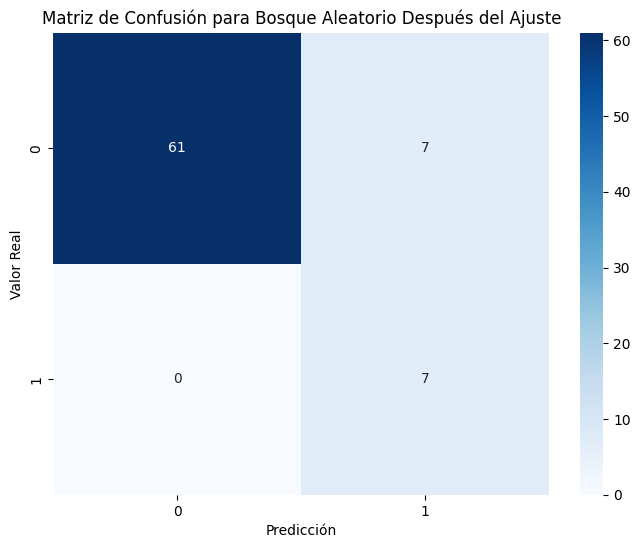

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

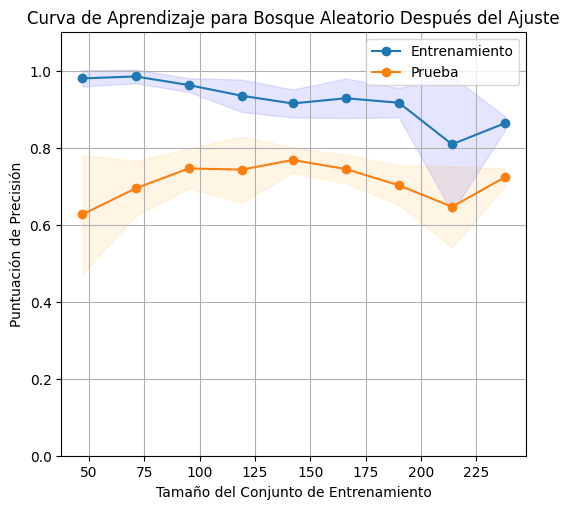

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): nan
Puntuación de Precisión (Prueba): nan
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 4700%
Puntuación de Precisión (Entrenamiento): 0.9800
Puntuación de Precisión (Prueba): 0.6267
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7100%
Puntuación de Precisión (Entrenamiento): 0.9852
Puntuación de Precisión (Prueba): 0.6943
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 9500%
Puntuación de Precisión (Entrenamiento): 0.9628
Puntuación de Precisión (Prueba): 0.7462
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 11900%
Puntuación de Precisión (Entrenamiento): 0.9350
Puntuación de Precisión (Prueba): 0.7431
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 14200%
Puntuación de Precisión (Entrenamiento): 0.9149
Puntuación de Precis

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Balanceo con SMOTE 
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Definir el modelo RandomForestClassifier con hiperparámetros ajustados
random_forest = RandomForestClassifier(random_state=42, class_weight={0: 1, 1: 20})

# Parámetros para GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

# Configuración de validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la búsqueda exhaustiva de hiperparámetros con GridSearchCV
grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    scoring='precision',
    cv=cv,
    n_jobs=-1  # Usa todos los núcleos disponibles
)

# Ajustar el modelo con los datos balanceados
grid_search.fit(X_train_bal, y_train_bal)

# Obtener el mejor modelo después del ajuste
best_rf = grid_search.best_estimator_

# Imprimir los mejores hiperparámetros encontrados
print("\nMejores hiperparámetros encontrados por GridSearchCV:")
print(grid_search.best_params_)

# Calibrar el modelo utilizando CalibratedClassifierCV
calibrated_rf = CalibratedClassifierCV(best_rf, method='sigmoid', cv=cv)
calibrated_rf.fit(X_train_bal, y_train_bal)

# Realizar predicciones con el modelo calibrado
y_pred = calibrated_rf.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.4f}")

precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo: {precision:.4f}")

report = classification_report(y_test, y_pred, target_names=[str(label) for label in calibrated_rf.classes_])
print("\nInforme de Clasificación:")
print(report)

confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=calibrated_rf.classes_),
                             index=calibrated_rf.classes_,
                             columns=calibrated_rf.classes_)
print("\nMatriz de Confusión:")
print(confusion_df)

# Calcular el AUC-ROC para la clase positiva
y_proba = calibrated_rf.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Ajustar el umbral de decisión
threshold = 0.6
y_pred = (y_proba >= threshold).astype(int)

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues", 
            xticklabels=calibrated_rf.classes_, yticklabels=calibrated_rf.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Bosque Aleatorio Después del Ajuste')
plt.show()

# Curva de aprendizaje con el modelo calibrado
train_sizes = np.linspace(0.1, 1.0, 10)
train_sizes, train_scores, test_scores = learning_curve(
    calibrated_rf, X_train, y_train, cv=cv, scoring='precision_macro', train_sizes=train_sizes)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.title('Curva de Aprendizaje para Bosque Aleatorio Después del Ajuste')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Puntuación de Precisión')
plt.ylim(0, 1.1)
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


### MODELO: XGBoost

##### Preliminar

Exactitud del modelo de XGBoost: 0.8800
Precisión del modelo de XGBoost: 0.3333

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93        68
           1       0.33      0.29      0.31         7

    accuracy                           0.88        75
   macro avg       0.63      0.61      0.62        75
weighted avg       0.87      0.88      0.88        75


Matriz de Confusión en texto:
    0  1
0  64  4
1   5  2

Área bajo la Curva ROC (AUC-ROC): 0.9328


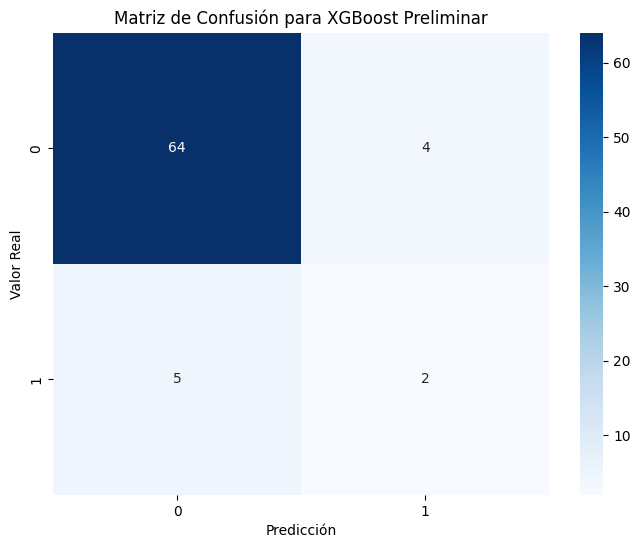

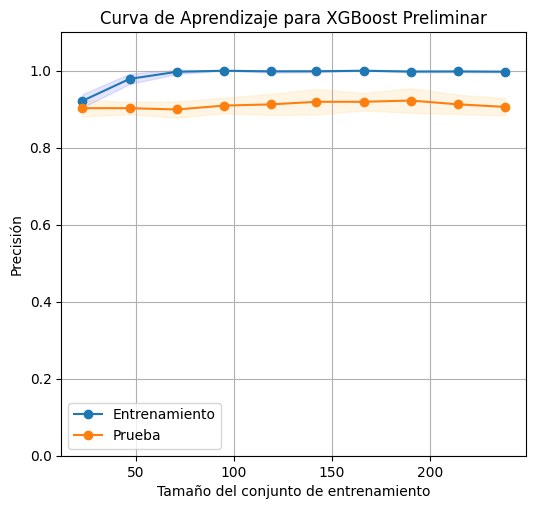

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 0.9217
Puntuación de Precisión (Prueba): 0.9028
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 4700%
Puntuación de Precisión (Entrenamiento): 0.9787
Puntuación de Precisión (Prueba): 0.9028
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7100%
Puntuación de Precisión (Entrenamiento): 0.9972
Puntuación de Precisión (Prueba): 0.8993
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 9500%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.9094
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 11900%
Puntuación de Precisión (Entrenamiento): 0.9983
Puntuación de Precisión (Prueba): 0.9126
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 14200%
Puntuación de Precisión (Entrenamiento): 0.9986
Puntuación de 

In [30]:
from xgboost import XGBClassifier
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Crear y entrenar el modelo de XGBoost
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = xgb.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo de XGBoost: {accuracy:.4f}")

precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo de XGBoost: {precision:.4f}")

# Convertir las clases en cadenas de texto
target_names = [str(cls) for cls in xgb.classes_]

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=target_names)
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=xgb.classes_),
                             index=xgb.classes_,
                             columns=xgb.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC
y_proba = xgb.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión (opcional)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=xgb.classes_, yticklabels=xgb.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para XGBoost Preliminar')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    xgb, X_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular la media y la desviación estándar de las puntuaciones de entrenamiento y prueba
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')

plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Precisión')
plt.title('Curva de Aprendizaje para XGBoost Preliminar')
plt.ylim(0, 1.1)  # Ajustar el rango del eje
plt.legend()
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


##### Aplicando SMOTE

Exactitud del modelo de XGBoost: 0.9067
Precisión del modelo de XGBoost: 0.5000

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        68
           1       0.50      0.71      0.59         7

    accuracy                           0.91        75
   macro avg       0.73      0.82      0.77        75
weighted avg       0.93      0.91      0.91        75


Matriz de Confusión en texto:
    0  1
0  63  5
1   2  5

Área bajo la Curva ROC (AUC-ROC): 0.9307


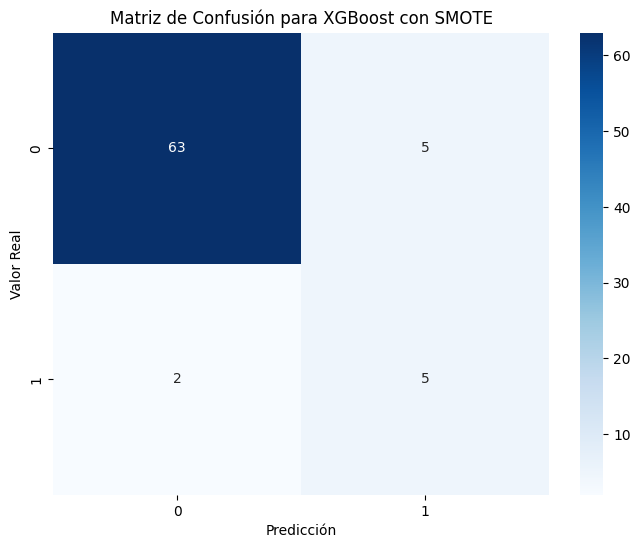

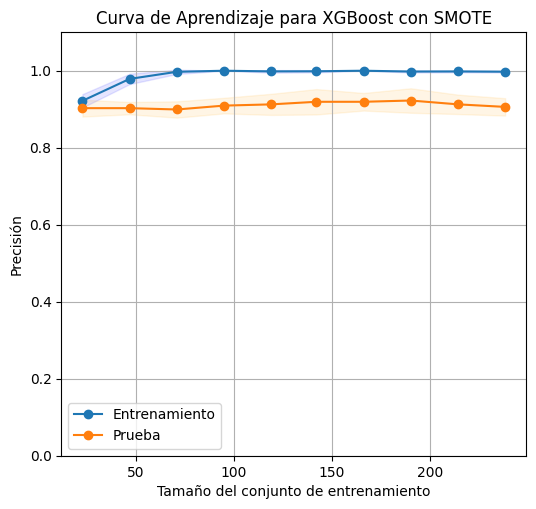

Curva de Aprendizaje:
Tamaño del Conjunto de Entrenamiento: 2300%
Puntuación de Precisión (Entrenamiento): 0.9217
Puntuación de Precisión (Prueba): 0.9028
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 4700%
Puntuación de Precisión (Entrenamiento): 0.9787
Puntuación de Precisión (Prueba): 0.9028
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 7100%
Puntuación de Precisión (Entrenamiento): 0.9972
Puntuación de Precisión (Prueba): 0.8993
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 9500%
Puntuación de Precisión (Entrenamiento): 1.0000
Puntuación de Precisión (Prueba): 0.9094
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 11900%
Puntuación de Precisión (Entrenamiento): 0.9983
Puntuación de Precisión (Prueba): 0.9126
----------------------------------------
Tamaño del Conjunto de Entrenamiento: 14200%
Puntuación de Precisión (Entrenamiento): 0.9986
Puntuación de 

In [31]:
from xgboost import XGBClassifier
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Aplicar SMOTE para balancear las clases
tsmote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Crear y entrenar el modelo de XGBoost
xgb = XGBClassifier()
xgb.fit(X_train_bal, y_train_bal)

# Realizar predicciones en el conjunto de prueba
y_pred = xgb.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo de XGBoost: {accuracy:.4f}")

precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo de XGBoost: {precision:.4f}")

# Convertir las clases en cadenas de texto
target_names = [str(cls) for cls in xgb.classes_]

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=target_names)
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=xgb.classes_),
                             index=xgb.classes_,
                             columns=xgb.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC
y_proba = xgb.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"\nÁrea bajo la Curva ROC (AUC-ROC): {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión (opcional)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=xgb.classes_, yticklabels=xgb.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para XGBoost con SMOTE')
plt.show()

# Calcular la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    xgb, X_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular la media y la desviación estándar de las puntuaciones de entrenamiento y prueba
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')

plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Precisión')
plt.title('Curva de Aprendizaje para XGBoost con SMOTE')
plt.ylim(0, 1.1)  # Ajustar el rango del eje
plt.legend()
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


##### Ajustado

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Aplicar SMOTE para equilibrar las clases en el conjunto de entrenamiento
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Crear el modelo de XGBoost
xgboost_model = XGBClassifier(
    scale_pos_weight=6,
    objective='binary:logistic',
    eval_metric='logloss'
)

# Definir los valores para la búsqueda de hiperparámetros
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],  
    'n_estimators': [30, 50, 100],  
    'max_depth': [4, 5, 6],  
    'subsample': [0.7, 0.8, 0.9], 
    'colsample_bytree': [0.7, 0.8],  
    'gamma': [0, 0.1], 
    'reg_alpha': [0, 0.1],  
    'reg_lambda': [1, 1.1]  
}

# Definir StratifiedKFold para la validación cruzada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Realizar la búsqueda en cuadrícula para optimizar los hiperparámetros
grid_search = GridSearchCV(
    estimator=xgboost_model,
    param_grid=param_grid,
    cv=cv,
    verbose=1,
    n_jobs=1,
    scoring='precision'
)

# Entrenar el modelo con la búsqueda en cuadrícula
grid_search.fit(X_train_bal, y_train_bal)

# Obtener el mejor modelo
best_xgb = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = best_xgb.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo de XGBoost: {accuracy:.4f}")

precision = precision_score(y_test, y_pred, average='binary')
print(f"Precisión del modelo de XGBoost: {precision:.4f}")

# Convertir las clases en cadenas de texto
target_names = [str(cls) for cls in best_xgb.classes_]

# Calcular el informe de clasificación
report = classification_report(y_test, y_pred, target_names=target_names)
print("\nInforme de Clasificación:")
print(report)

# Calcular y mostrar la matriz de confusión en texto
confusion_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=best_xgb.classes_),
                             index=best_xgb.classes_,
                             columns=best_xgb.classes_)
print("\nMatriz de Confusión en texto:")
print(confusion_df)

# Calcular el AUC-ROC para cada clase
auc_roc_scores = {class_label: roc_auc_score(y_test == class_label, y_pred == class_label) 
                  for class_label in best_xgb.classes_}

# Imprimir el AUC-ROC para cada clase
print("\nÁrea bajo la Curva ROC (AUC-ROC) para cada clase:")
for class_label, auc_roc in auc_roc_scores.items():
    print(f"{class_label}: {auc_roc:.4f}")

# Calcular y graficar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=best_xgb.classes_, yticklabels=best_xgb.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para XGBoost ajustado con SMOTE')
plt.show()

# Calcular la curva de aprendizaje
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_xgb, X_train_bal, y_train_bal, cv=3, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calcular la media y la desviación estándar de las puntuaciones de entrenamiento y prueba
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(6, 5.5))
plt.plot(train_sizes, train_scores_mean, label='Entrenamiento', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')

plt.plot(train_sizes, test_scores_mean, label='Prueba', marker='o')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='orange')

plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Precisión')
plt.title('Curva de Aprendizaje para XGBoost ajustado con SMOTE')
plt.ylim(0, 1.1)  # Ajustar el rango del eje
plt.legend()
plt.grid()
plt.show()

# Imprimir la curva de aprendizaje en texto
print("Curva de Aprendizaje:")
for size, train_score, test_score in zip(train_sizes, train_scores, test_scores):
    print(f"Tamaño del Conjunto de Entrenamiento: {size * 100:.0f}%")
    print(f"Puntuación de Precisión (Entrenamiento): {np.mean(train_score):.4f}")
    print(f"Puntuación de Precisión (Prueba): {np.mean(test_score):.4f}")
    print("-" * 40)


Fitting 3 folds for each of 1296 candidates, totalling 3888 fits


In [ ]:
# Obtener la importancia de las características
importancias = best_xgb.feature_importances_

# Crear un DataFrame con las variables y su importancia
df_importancia = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})

# Ordenar de mayor a menor importancia
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Mostrar la importancia de las variables
print(df_importancia)